In [1]:
using IonSim
using QuantumOptics
using PyPlot
using LinearAlgebra

In [22]:

angle = 0
target_alpha = 0.716
 cat_state = false
 initial_state = nothing
 fock_state_n = 0
    red_angle = (π - 2*angle ) /2
    blue_angle = red_angle + 2 *angle

    if (cat_state)
        # println("Preparing cat state superposi/tion...")
        red_angle = -angle
        blue_angle = angle
    end
    
    trap_freq = 19e5 # 1.9 MHz trap frequency
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))

    mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
    mode_z.N = 10

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ

    laser_intensity = 1e4 # Fixed intensity
    B_field = 1e-13
    
    # Pre-build a trap just to grab the transition wavelength
    trap_pre = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap_pre)

    # ---------------------------------------------------------
    # NEW: DYNAMIC TIME CALCULATION VIA WIGNER-ECKART ENGINE
    # ---------------------------------------------------------
    hbar = 1.0545718e-34       
    amu = 1.66053906e-27       
    m_Ca40 = 39.96259 * amu    
    c = 2.99792458e8           

    # 1. Calculate Lamb-Dicke Parameter (η) dynamically
    omega_trap = 2 * π * trap_freq
    z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
    k_total = 2 * π / transition_λ
    k_z = k_total / sqrt(2)
    eta = k_z * z_zpf

    # 2. Hijack IonSim's internal matrix element calculator
    dummy_laser = Laser(I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    Bhat_tuple = (; x=0.0, y=0.0, z=1.0)
    
    # Feed the dummy laser into the exact internal physics engine
    # (Note: Unexported internal functions need the module prefix 'IonSim.')
    Omega_eff_Hz = IonSim.matrixelement(ion, ("g", "e"), laser_intensity, polarization(dummy_laser), wavevector(dummy_laser), Bhat_tuple)
    Omega_eff = Omega_eff_Hz * 2 * π
    # 3. Solve the displacemen formula backward to find exactly how long to leave the lasers on
    target_time_s = (2 * target_alpha) / (eta * Omega_eff)
    target_time_us = target_time_s * 1e6
    # ---------------------------------------------------------

    # Now build the actual lasers and final chamber
    L_red = Laser(Δ = -trap_freq, ϕ=red_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    L_blue = Laser(Δ = trap_freq, ϕ=blue_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])

    mode = zmodes(trap)[1]
    # println(mode)

    ψ_ion = normalize(ion["g"] - ion["e"])
    ψ_mode = fockstate(mode, fock_state_n)
    ψ_initial = ψ_ion ⊗ ψ_mode

    if (initial_state != nothing)
        ψ_initial = initial_state
    end

    h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
    
    # Ensure our solver array steps exactly up to our calculated target time
    tspan_array = collect(0:0.5:target_time_us)
    if tspan_array[end] < target_time_us
        push!(tspan_array, target_time_us)
    end

    tout, sol = timeevolution.schroedinger_dynamic(tspan_array, ψ_initial, h)

    final_state = sol[end]


Ket(dim=22)
  basis: [⁴⁰Ca ⊗ VibrationalMode(ν=1.9e6, axis=ẑ, N=10)]
   0.5450724734244152 + 1.404863281754e-5im
  -0.5500630133083152 - 1.366575032934e-5im
   -5.423294328424e-5 + 0.38992256197509145im
    5.364898271983e-5 - 0.39348372055944586im
 -0.19699261794464973 - 5.015637022388e-5im
  0.19878811173438476 + 4.970955984706e-5im
    3.021923572959e-5 - 0.08115997289155563im
    -2.99744485765e-5 + 0.08189715939831442im
  0.02892162654602662 + 1.423757847265e-5im
 -0.02918404454742192 - 1.412949519357e-5im
                      ⋮
  0.00269638276178352 + 1.96050688565e-6im
      6.2058622637e-7 - 0.00071718795632772im
     -6.1644583554e-7 + 0.00072363098620465im
  0.00017983715843319 + 1.7873859289e-7im
 -0.00018145417018695 - 1.7758980745e-7im
      -4.784872924e-8 + 4.237047749384e-5im
       4.754938748e-8 - 4.274901408237e-5im
    -9.93723672006e-6 - 1.158922325e-8im
    1.002741690395e-5 + 1.152234452e-8im

In [2]:
function SDF_apply_with_alpha(angle = 0, target_alpha = 0.716, cat_state = false, initial_state = nothing, fock_state_n = 0)

    red_angle = (π - 2*angle ) /2
    blue_angle = red_angle + 2 *angle

    if (cat_state)
        # println("Preparing cat state superposi/tion...")
        red_angle = -angle
        blue_angle = angle
    end
    
    trap_freq = 19e5 # 1.9 MHz trap frequency
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))

    mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
    mode_z.N = 10

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ

    laser_intensity = 1e4 # Fixed intensity
    B_field = 1e-13
    
    # Pre-build a trap just to grab the transition wavelength
    trap_pre = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap_pre)

    # ---------------------------------------------------------
    # NEW: DYNAMIC TIME CALCULATION VIA WIGNER-ECKART ENGINE
    # ---------------------------------------------------------
    hbar = 1.0545718e-34       
    amu = 1.66053906e-27       
    m_Ca40 = 39.96259 * amu    
    c = 2.99792458e8           

    # 1. Calculate Lamb-Dicke Parameter (η) dynamically
    omega_trap = 2 * π * trap_freq
    z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
    k_total = 2 * π / transition_λ
    k_z = k_total / sqrt(2)
    eta = k_z * z_zpf

    # 2. Hijack IonSim's internal matrix element calculator
    dummy_laser = Laser(I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    Bhat_tuple = (; x=0.0, y=0.0, z=1.0)
    
    # Feed the dummy laser into the exact internal physics engine
    # (Note: Unexported internal functions need the module prefix 'IonSim.')
    Omega_eff_Hz = IonSim.matrixelement(ion, ("g", "e"), laser_intensity, polarization(dummy_laser), wavevector(dummy_laser), Bhat_tuple)
    Omega_eff = Omega_eff_Hz * 2 * π
    # 3. Solve the displacemen formula backward to find exactly how long to leave the lasers on
    target_time_s = (2 * target_alpha) / (eta * Omega_eff)
    target_time_us = target_time_s * 1e6
    # ---------------------------------------------------------

    # Now build the actual lasers and final chamber
    L_red = Laser(Δ = -trap_freq, ϕ=red_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    L_blue = Laser(Δ = trap_freq, ϕ=blue_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])

    mode = zmodes(trap)[1]
    # println(mode)

    ψ_ion = normalize(ion["g"] - ion["e"])
    ψ_mode = fockstate(mode, fock_state_n)
    ψ_initial = ψ_ion ⊗ ψ_mode

    if (initial_state != nothing)
        ψ_initial = initial_state
    end

    h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
    
    # Ensure our solver array steps exactly up to our calculated target time
    tspan_array = collect(0:0.5:target_time_us)
    if tspan_array[end] < target_time_us
        push!(tspan_array, target_time_us)
    end

    tout, sol = timeevolution.schroedinger_dynamic(tspan_array, ψ_initial, h)

    final_state = sol[end]
    
    return final_state
end

SDF_apply_with_alpha (generic function with 6 methods)

In [3]:
function calculate_qcrb(state, state_perturbed, d_alpha::Float64; tol=1e-10)
    
    # 1. Promote pure states (Ket) to density matrices
    rho1 = isa(state, Ket) ? dm(state) : state
    rho2 = isa(state_perturbed, Ket) ? dm(state_perturbed) : state_perturbed
    
    # 2. Extract dense data
    rho_dense_data = dense(rho1).data
    rho_pert_dense_data = dense(rho2).data

    # 3. Finite difference derivative
    drho_data = (rho_pert_dense_data - rho_dense_data) / d_alpha
    
    # 4. Use Hermitian() to guarantee real eigenvalues and speed up diagonalization
    λ, V = LinearAlgebra.eigen(Hermitian(rho_dense_data))
    
    qfi = 0.0
    n = length(λ)
    
    for i in 1:n
        for j in 1:n
            if real(λ[i] + λ[j]) > tol
                # 5. Use @views to prevent memory allocation during column slicing
                @views v_i = V[:, i]
                @views v_j = V[:, j]
                
                drho_ij = dot(v_i, drho_data * v_j)
                qfi += 2 * (abs(drho_ij)^2) / real(λ[i] + λ[j])
            end
        end
    end
    
    qcrb = qfi > 0 ? 1.0 / qfi : Inf
    return qfi, qcrb
end


calculate_qcrb (generic function with 1 method)

In [4]:
function plot_wigner(final_state)
    rho_motional = ptrace(final_state, 1)

b_fock = FockBasis(10)
rho_fock = DenseOperator(b_fock, rho_motional.data)

x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

W = wigner(rho_fock, x_vec, p_vec)

fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W, cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)
end


plot_wigner (generic function with 1 method)

In [7]:
SDF_apply_with_alpha(0, 0.1, false,nothing,  0)

Ket(dim=22)
  basis: [⁴⁰Ca ⊗ VibrationalMode(ν=1.9e6, axis=ẑ, N=10)]
   0.7052972022401989 - 2.07673751463e-6im
  -0.7018703541299468 + 2.05251397608e-6im
   -2.131067131175e-5 + 0.07047957947910935im
    2.134968087693e-5 - 0.0701362307015102im
 -0.00497381132147204 - 3.0220735771e-6im
  0.00494981935232057 + 3.02736013926e-6im
      2.6126321681e-7 - 0.00028625890507633im
     -2.6171648448e-7 + 0.00028485690439277im
    1.424892558733e-5 + 1.735190731e-8im
   -1.418069894275e-5 - 1.738149066e-8im
                      ⋮
       2.556734386e-8 + 4.702834e-11im
          2.05362e-12 - 9.6318893e-10im
         -2.05707e-12 + 9.5842242e-10im
         3.373193e-11 + 8.221e-14im
        -3.357284e-11 - 8.234e-14im
            -3.05e-15 + 1.11264e-12im
             3.06e-15 - 1.10711e-12im
           -3.495e-14 - 1.1e-16im
            3.479e-14 + 1.1e-16im

In [8]:
final_state = SDF_apply_with_alpha(0, 0.1, false,nothing,  0)

println("Final state after SDF application: ", final_state)

Final state after SDF application: Ket(dim=22)
  basis: [⁴⁰Ca ⊗ VibrationalMode(ν=1.9e6, axis=ẑ, N=10)]
   0.7052972022401989 - 2.07673751463e-6im
  -0.7018703541299468 + 2.05251397608e-6im
   -2.131067131175e-5 + 0.07047957947910935im
    2.134968087693e-5 - 0.0701362307015102im
 -0.00497381132147204 - 3.0220735771e-6im
  0.00494981935232057 + 3.02736013926e-6im
      2.6126321681e-7 - 0.00028625890507633im
     -2.6171648448e-7 + 0.00028485690439277im
    1.424892558733e-5 + 1.735190731e-8im
   -1.418069894275e-5 - 1.738149066e-8im
       -9.6482821e-10 + 6.3367379825e-7im
        9.6647072e-10 - 6.3055398884e-7im
      -2.568942892e-8 - 4.694939e-11im
       2.556734386e-8 + 4.702834e-11im
          2.05362e-12 - 9.6318893e-10im
         -2.05707e-12 + 9.5842242e-10im
         3.373193e-11 + 8.221e-14im
        -3.357284e-11 - 8.234e-14im
            -3.05e-15 + 1.11264e-12im
             3.06e-15 - 1.10711e-12im
           -3.495e-14 - 1.1e-16im
            3.479e-14 + 1.1e-16im


In [13]:
base = ptrace(final_state, 1)

Operator(dim=11x11)
  basis: VibrationalMode(ν=1.9e6, axis=ẑ, N=10)
    0.990066+0.0im          …  -4.907e-14+1.5e-16im
 -3.03054e-5+0.0989356im         -1.0e-17-4.9e-15im
 -0.00698215-4.27676e-6im         3.5e-16-0.0im
  3.69138e-7-0.00040183im             0.0+2.0e-17im
  2.00027e-5+2.44965e-8im            -0.0+0.0im
 -1.36144e-9+8.89496e-7im   …        -0.0-0.0im
 -3.60636e-8-6.62269e-11im            0.0-0.0im
 2.89618e-12-1.35202e-9im             0.0+0.0im
 4.73548e-11+1.1591e-13im            -0.0+0.0im
    -4.3e-15+1.56179e-12im           -0.0-0.0im
  -4.907e-14-1.5e-16im      …         0.0+0.0im

In [11]:
base_spin = ptrace(final_state, 2)

Operator(dim=2x2)
  basis: ⁴⁰Ca
  0.502436+0.0im         -0.499995+2.01338e-8im
 -0.499995-2.01338e-8im   0.497566+0.0im

In [14]:
println(base)

Operator(dim=11x11)
  basis: VibrationalMode(ν=1.9e6, axis=ẑ, N=10)
    0.990066+0.0im           -3.03054e-5-0.0989356im     -0.00698215+4.27676e-6im     3.69138e-7+0.00040183im     2.00027e-5-2.44965e-8im    -1.36144e-9-8.89496e-7im    -3.60636e-8+6.62269e-11im   2.89618e-12+1.35202e-9im   4.73548e-11-1.1591e-13im     -4.3e-15-1.56179e-12im  -4.907e-14+1.5e-16im
 -3.03054e-5+0.0989356im      0.00988646+0.0im            -2.1365e-7-0.000697714im   -4.01542e-5+2.45876e-8im     1.83562e-9+1.99884e-6im     8.88858e-8-1.08819e-10im  -5.51405e-12-3.60378e-9im   -1.35105e-10+2.4803e-13im     1.013e-14+4.73209e-12im  1.5607e-13-3.8e-16im        -1.0e-17-4.9e-15im
 -0.00698215-4.27676e-6im     -2.1365e-7+0.000697714im    4.92395e-5+0.0im          -8.67463e-10-2.83379e-6im    -1.41063e-7+8.6349e-11im    5.75881e-12+6.27291e-9im    2.54328e-10-3.1126e-13im     -1.458e-14-9.53475e-12im  -3.3396e-13+6.1e-16im         2.0e-17+1.101e-14im       3.5e-16-0.0im
  3.69138e-7-0.00040183im    -4.01542e-5-

In [23]:
raw_data = final_state.data

# 2. Slice out just the |g⟩ spin components (every odd index: 1, 3, 5... 21)
# This instantly reduces the array from 22 dimensions down to 11
g_amplitudes = raw_data[1:2:end]

# 3. Restore Normalization
# Because the spin was in a superposition, these amplitudes are currently 
# scaled by 1/sqrt(2). We multiply by sqrt(2) to restore the probabilities to 100%.
motional_amplitudes = g_amplitudes .* sqrt(2)

# 4. Wrap the raw 11-element array back into a pure QuantumOptics Ket!
mode_z = zmodes(trap)[1] # Ensure your mode has N=10 so dim=11 matches
motional_ket = Ket(mode_z, motional_amplitudes)

println(motional_ket)

Ket(dim=11)
  basis: VibrationalMode(ν=1.9e6, axis=ẑ, N=10)
   0.7708488843930564 + 1.986776706336e-5im
   -7.669696391998e-5 + 0.551433775420438im
 -0.27858963198470515 - 7.093181901002e-5im
    4.273645301334e-5 - 0.11477753438507073im
  0.04090135650728058 + 2.013497657137e-5im
    -8.00014748411e-6 + 0.01302065534617506im
 -0.00377912641172163 - 2.79188873363e-6im
      8.7764145795e-7 - 0.00101425693460931im
  0.00025432814847485 + 2.5277454218e-7im
      -6.766832184e-8 + 5.992090391601e-5im
   -1.405337494203e-5 - 1.638963669e-8im


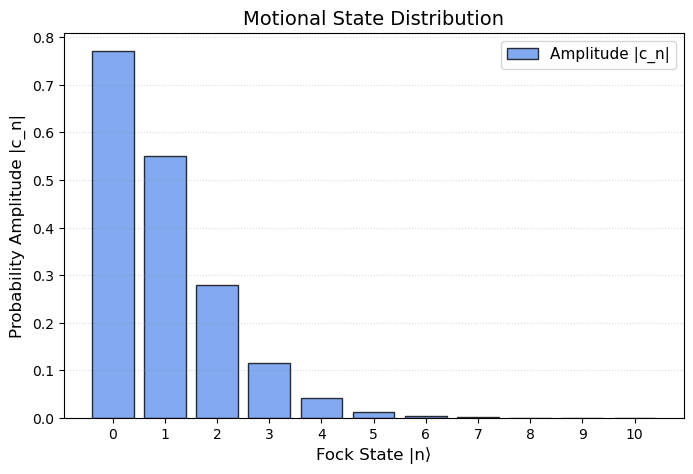

In [ ]:

c_n_array = motional_ket.data
amplitudes = abs.(c_n_array)
fock_states = 0:10 
fig = figure(figsize=(8, 5))

# Plot as a bar chart for discrete states
PyPlot.bar(fock_states, amplitudes, color="cornflowerblue", edgecolor="black", alpha=0.8, label="Amplitude |c_n|")

# Force the X-axis to display every single integer 
PyPlot.xticks(fock_states) 

PyPlot.xlabel("Fock State |n⟩", fontsize=12)
PyPlot.ylabel("Probability Amplitude |c_n|", fontsize=12)
PyPlot.title("Motional State Distribution", fontsize=14)

PyPlot.legend(loc="upper right", fontsize=11)
PyPlot.grid(axis="y", color="gray", alpha=0.3, linestyle=":") # Only grid the Y-axis for bar charts

display(fig)

In [25]:
println( zmodes(trap)[1])

VibrationalMode(ν=1.9e6, axis=ẑ, N=10)


In [40]:
mode_z = VibrationalMode(1.9e6, [1.0], axis=ẑ, N=10)

VibrationalMode(ν=1.9e6, axis=ẑ, N=10)

In [37]:
print(VibrationalMode(1.9e6, ẑ, N=10))

MethodError: MethodError: Cannot `convert` an object of type @NamedTuple{x::Int64, y::Int64, z::Int64} to an object of type Vector{Real}
The function `convert` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  convert(::Type{Array{T, N}}, !Matched::StaticArraysCore.SizedArray{S, T, N, N, Array{T, N}}) where {S, T, N}
   @ StaticArrays C:\Users\jewoo\.julia\packages\StaticArrays\DsPgf\src\SizedArray.jl:88
  convert(::Type{Array{T, N}}, !Matched::StaticArraysCore.SizedArray{S, T, N, M, TData} where {M, TData<:AbstractArray{T, M}}) where {T, S, N}
   @ StaticArrays C:\Users\jewoo\.julia\packages\StaticArrays\DsPgf\src\SizedArray.jl:82
  convert(::Type{T}, !Matched::AbstractArray) where T<:Array
   @ Base array.jl:614
  ...


In [49]:
function extract_motional_ket(final_state)
raw_data = final_state.data

# 2. Slice out just the |g⟩ spin components (every odd index: 1, 3, 5... 21)
# This instantly reduces the array from 22 dimensions down to 11
g_amplitudes = raw_data[1:2:end]

# 3. Restore Normalization
# Because the spin was in a superposition, these amplitudes are currently 
# scaled by 1/sqrt(2). We multiply by sqrt(2) to restore the probabilities to 100%.
motional_amplitudes = g_amplitudes .* sqrt(2)

# 4. Wrap the raw 11-element array back into a pure QuantumOptics Ket!
mode_z = VibrationalMode(1.9e6, [1.0], axis=ẑ, N=10) # Ensure your mode has N=10 so dim=11 matches
motional_ket = Ket(mode_z, motional_amplitudes)

# println(motional_ket)


c_n_array = motional_ket.data
amplitudes = abs.(c_n_array)
fock_states = 0:10 
fig = figure(figsize=(8, 5))

# Plot as a bar chart for discrete states
PyPlot.bar(fock_states, amplitudes, color="cornflowerblue", edgecolor="black", alpha=0.8, label="Amplitude |c_n|")

# Force the X-axis to display every single integer 
PyPlot.xticks(fock_states) 

PyPlot.xlabel("Fock State |n⟩", fontsize=12)
PyPlot.ylabel("Probability Amplitude |c_n|", fontsize=12)
PyPlot.title("Motional State Distribution", fontsize=14)

PyPlot.legend(loc="upper right", fontsize=11)
PyPlot.grid(axis="y", color="gray", alpha=0.3, linestyle=":") # Only grid the Y-axis for bar charts

display(fig)

return fig

end

extract_motional_ket (generic function with 2 methods)

In [42]:
shift1 = SDF_apply_with_alpha(0, 0.1, false,nothing,  0)
shift2 = SDF_apply_with_alpha(0, 0.5, false,nothing,  0)
shift3 = SDF_apply_with_alpha(0, 0.8, false,nothing,  0)


Ket(dim=22)
  basis: [⁴⁰Ca ⊗ VibrationalMode(ν=1.9e6, axis=ẑ, N=10)]
   0.5160278414485822 + 8.31550250384e-6im
  -0.5116270484454323 - 8.68616184811e-6im
   -3.785145395107e-5 + 0.4125314504583232im
    3.843299604295e-5 - 0.4090220887101312im
 -0.23291032699860692 - 3.946056849681e-5im
  0.23093458688352636 + 3.994523327306e-5im
    2.671467454504e-5 - 0.1072358970692628im
   -2.700753717413e-5 + 0.1063276924172388im
  0.04270524796721156 + 1.412879368388e-5im
 -0.04234492000092336 - 1.427238302117e-5im
                      ⋮
   0.0048864612782094 + 2.4881596523e-6im
      8.6926801857e-7 - 0.00147797948278865im
     -8.7685033777e-7 + 0.00146557309479115im
  0.00041419618599823 + 2.8072196659e-7im
  -0.0004107387757354 - 2.8307644087e-7im
      -8.435478025e-8 + 0.00010893588432024im
        8.50376795e-8 - 0.00010802556178528im
   -2.887120585712e-5 - 2.25500689e-8im
      2.8628206607e-5 + 2.272076379e-8im

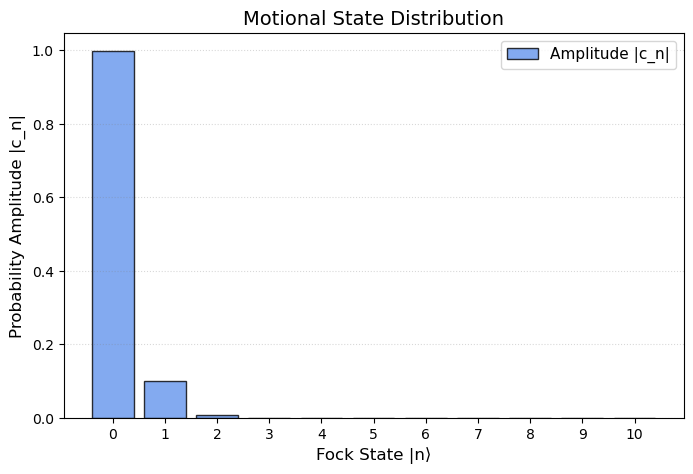

Ket(dim=11)
  basis: VibrationalMode(ν=1.9e6, axis=ẑ, N=10)
    0.997440868911889 - 2.93695035867e-6im
   -3.013784039236e-5 + 0.09967317716970892im
 -0.00703403142751061 - 4.27385743923e-6im
      3.6948198456e-7 - 0.00040483122590902im
    2.015102381485e-5 + 2.453930266e-8im
       -1.36447314e-9 + 8.961500796e-7im
      -3.633033879e-8 - 6.639647e-11im
          2.90426e-12 - 1.36215485e-9im
         4.770415e-11 + 1.1626e-13im
            -4.31e-15 + 1.57352e-12im
           -4.943e-14 - 1.5e-16im
Ket(dim=11)
  basis: VibrationalMode(ν=1.9e6, axis=ẑ, N=10)
   0.8848192629932261 - 1.737741579049e-5im
    -4.95243156325e-6 + 0.441892984025706im
 -0.15585696518718292 - 6.92343400568e-6im
      3.5862224049e-6 - 0.04482886229527928im
  0.01115258755878769 + 1.31531466524e-6im
     -3.9218698412e-7 + 0.00247862869251537im
 -0.00050223467609428 - 1.0088897783e-7im
       2.313688878e-8 - 9.410359972055e-5im
    1.647248310504e-5 + 4.83014561e-9im
       -9.2978199e-10 + 2.71363164092e

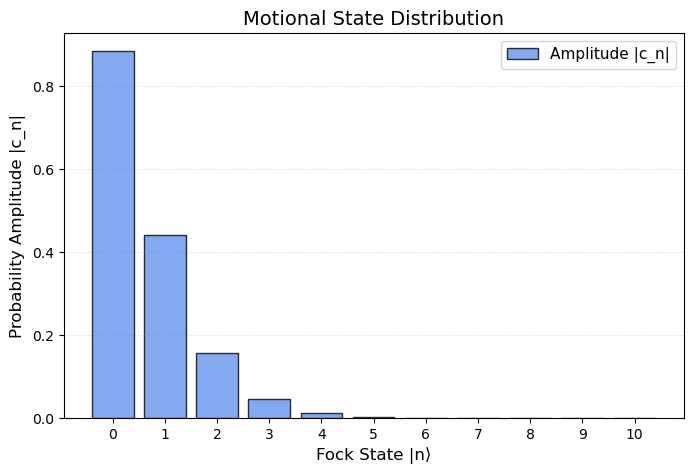

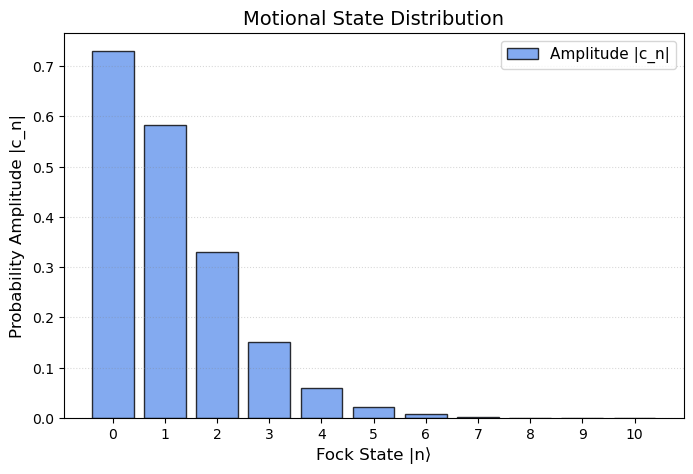

In [43]:
extract_motional_ket(shift1)
extract_motional_ket(shift2)
extract_motional_ket(shift3)

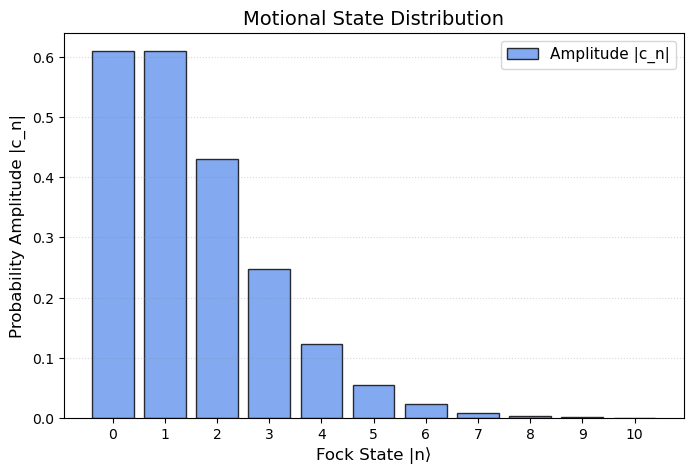

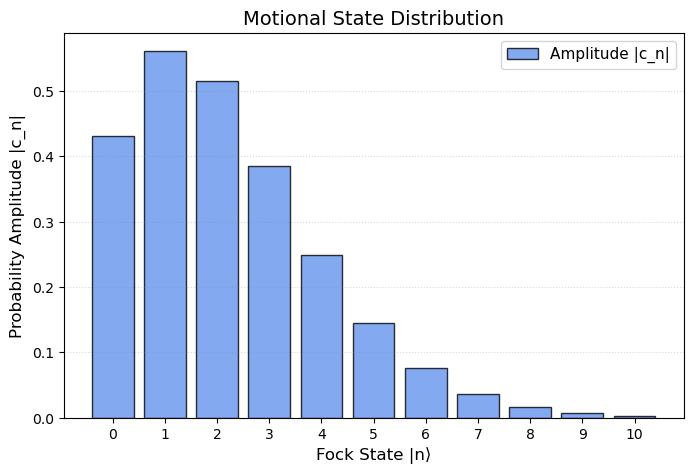

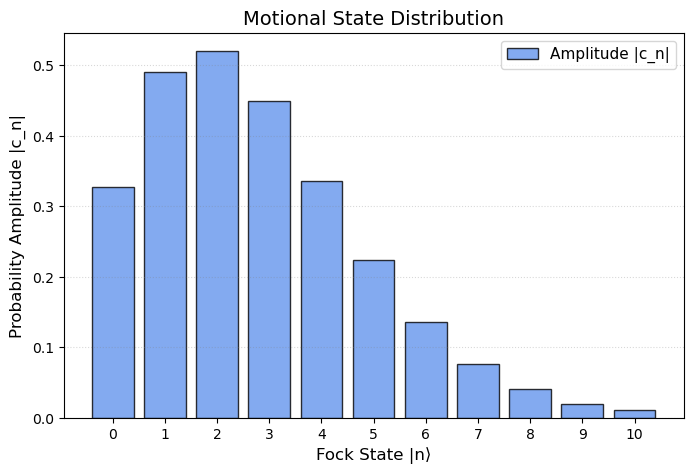

In [45]:
shift4 = SDF_apply_with_alpha(0, 1.0, false,nothing,  0)
shift5 = SDF_apply_with_alpha(0, 1.3, false,nothing,  0)
shift6 = SDF_apply_with_alpha(0, 1.5, false,nothing,  0)

extract_motional_ket(shift4)
extract_motional_ket(shift5)    
extract_motional_ket(shift6)

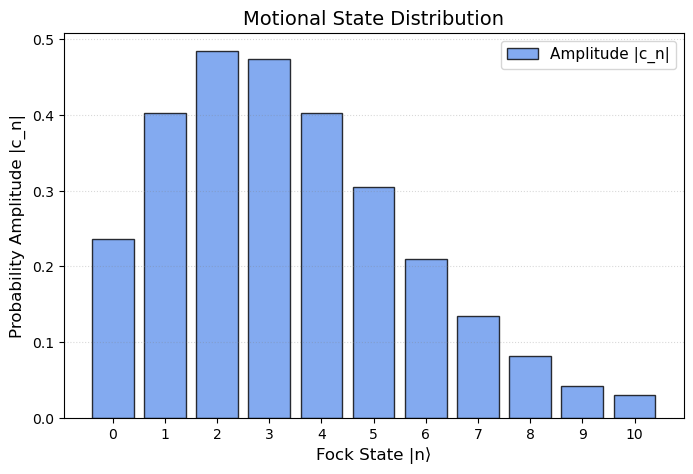

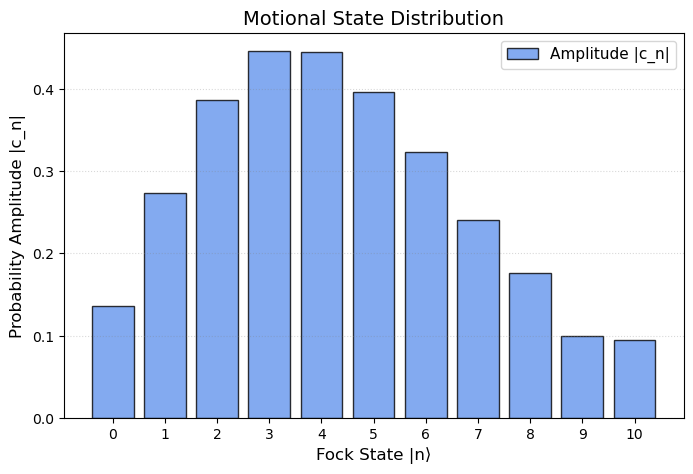

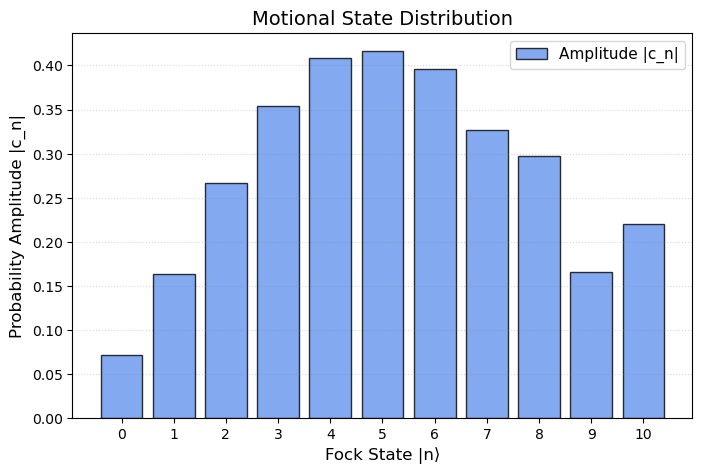

In [46]:
shift7 = SDF_apply_with_alpha(0, 1.7, false,nothing,  0)
shift8 = SDF_apply_with_alpha(0, 2.0, false,nothing,  0)
shift9 = SDF_apply_with_alpha(0, 2.3, false,nothing,  0)

extract_motional_ket(shift7)
extract_motional_ket(shift8)
extract_motional_ket(shift9)

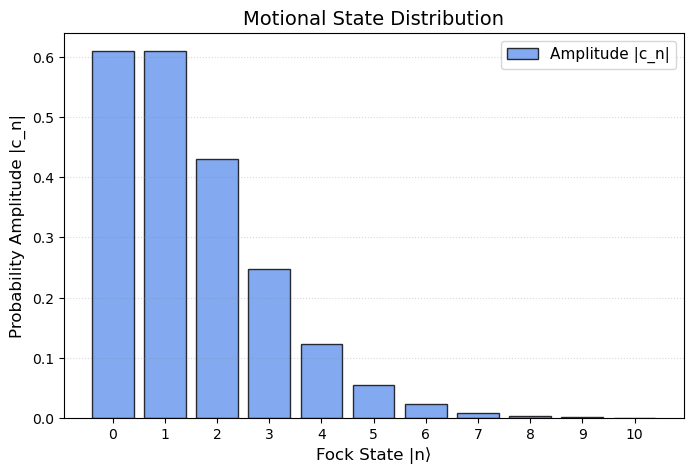

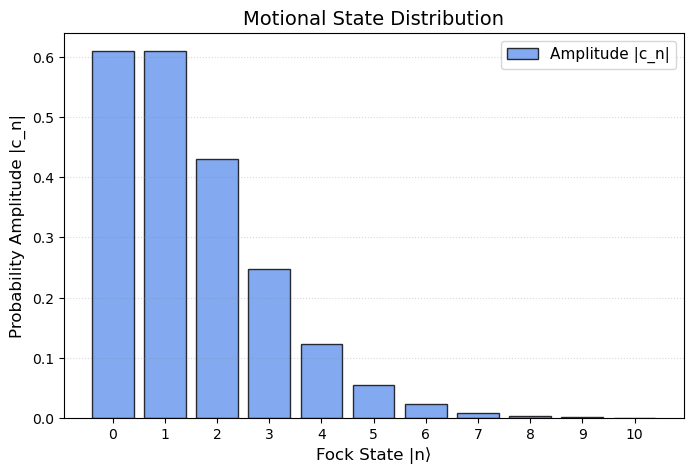

In [51]:
experiment_base = SDF_apply_with_alpha(0, 1.0, false,nothing,  0)
fig = extract_motional_ket(experiment_base)

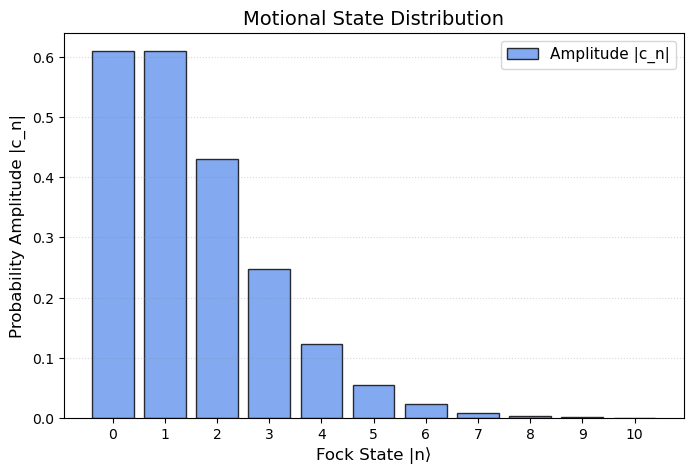

In [52]:
display(fig)

In [55]:
import Pkg
Pkg.add("SpecialFunctions")

    Updating registry at `C:\Users\jewoo\.julia\registries\General.toml`
   Resolving package versions...
   Installed SpecialFunctions ─ v2.8.0
    Updating `C:\Users\jewoo\projects\TestJulia\Project.toml`
  [276daf66] + SpecialFunctions v2.8.0 [loaded: v2.6.1]
    Updating `C:\Users\jewoo\projects\TestJulia\Manifest.toml`
  [276daf66] ↑ SpecialFunctions v2.6.1 ⇒ v2.8.0 [loaded: v2.6.1]
Precompiling packages...
   3451.4 ms  ✓ SpecialFunctions
   5672.7 ms  ✓ SpecialFunctions → SpecialFunctionsChainRulesCoreExt
  2 dependencies successfully precompiled in 47 seconds. 458 already precompiled.
  2 dependencies precompiled but different versions are currently loaded. Restart julia to access the new versions. Otherwise, loading dependents of these packages may trigger further precompilation to work with the unexpected versions.


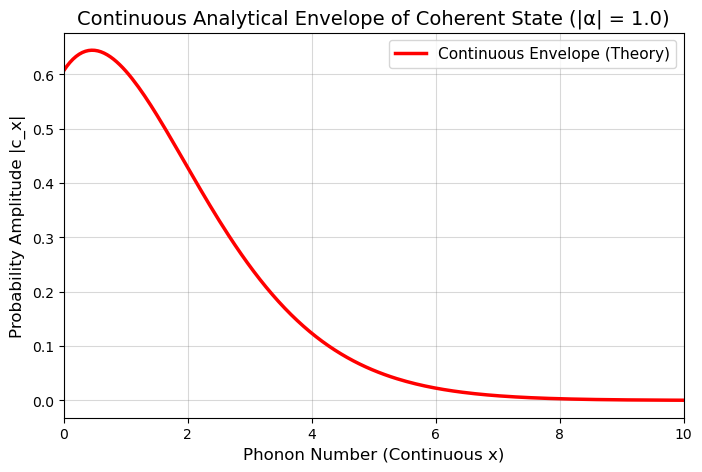

In [57]:
using SpecialFunctions # This package contains the gamma() function

# 1. Define fixed Alpha
target_alpha = 1.0

# 2. Define a continuous, high-resolution X-axis (e.g., 0.0, 0.1, 0.2... 10.0)
x_continuous = range(0, stop=10, length=200)

# 3. Calculate the continuous analytical envelope
# Formula: |c_x| = exp(-|α|^2 / 2) * (|α|^x) / sqrt(Γ(x + 1))
# (We use the `@.` macro to apply the math element-by-element across the whole array)
analytical_continuous = @. exp(-target_alpha^2 / 2) * (target_alpha^x_continuous) / sqrt(gamma(x_continuous + 1))

# 4. Generate the Plot
fig = figure(figsize=(8, 5))

# Plot the smooth continuous line
PyPlot.plot(x_continuous, analytical_continuous, color="red", linewidth=2.5, linestyle="-", label="Continuous Envelope (Theory)")

# Formatting
PyPlot.xlim(0, 10) # Lock the X-axis from 0 to 10
PyPlot.xlabel("Phonon Number (Continuous x)", fontsize=12)
PyPlot.ylabel("Probability Amplitude |c_x|", fontsize=12)
PyPlot.title("Continuous Analytical Envelope of Coherent State (|α| = $target_alpha)", fontsize=14)

PyPlot.legend(loc="upper right", fontsize=11)
PyPlot.grid(which="major", color="gray", alpha=0.3, linestyle="-")

display(fig)

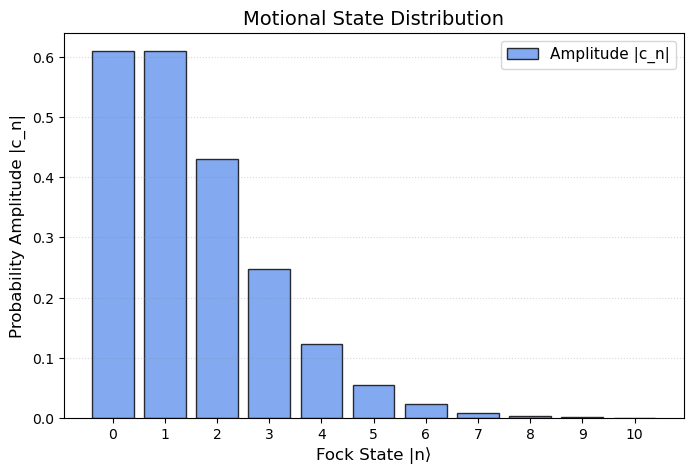

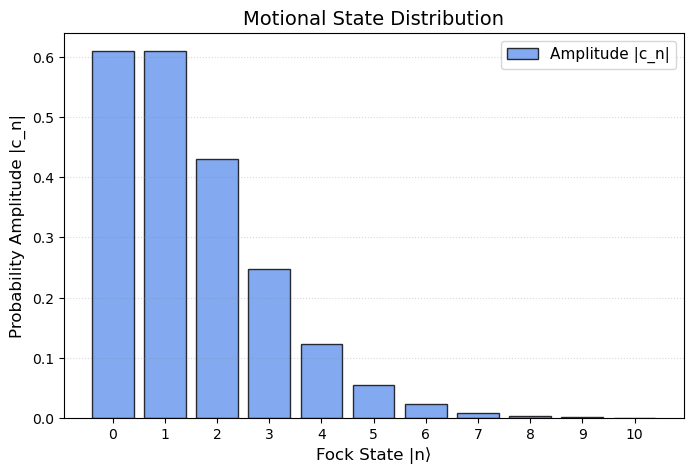

In [58]:
experiment_base = SDF_apply_with_alpha(0, 1.0, false,nothing,  0)
fig = extract_motional_ket(experiment_base)

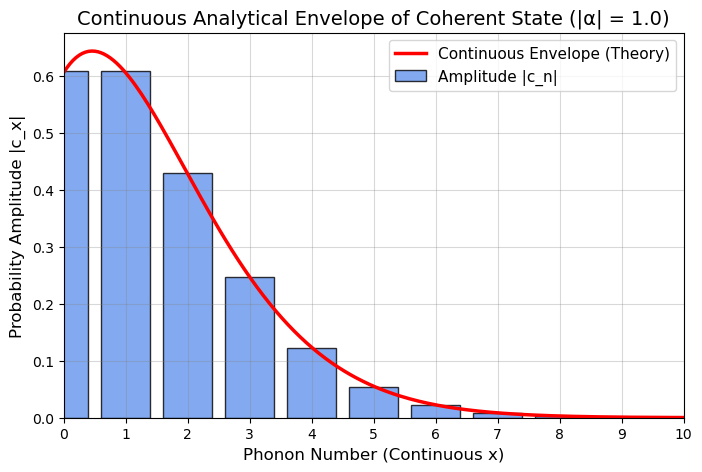

In [59]:
target_alpha = 1.0

x_continuous = range(0, stop=10, length=200)

analytical_continuous = @. exp(-target_alpha^2 / 2) * (target_alpha^x_continuous) / sqrt(gamma(x_continuous + 1))

PyPlot.plot(x_continuous, analytical_continuous, color="red", linewidth=2.5, linestyle="-", label="Continuous Envelope (Theory)")

PyPlot.xlim(0, 10) # Lock the X-axis from 0 to 10
PyPlot.xlabel("Phonon Number (Continuous x)", fontsize=12)
PyPlot.ylabel("Probability Amplitude |c_x|", fontsize=12)
PyPlot.title("Continuous Analytical Envelope of Coherent State (|α| = $target_alpha)", fontsize=14)

PyPlot.legend(loc="upper right", fontsize=11)
PyPlot.grid(which="major", color="gray", alpha=0.3, linestyle="-")

display(fig)

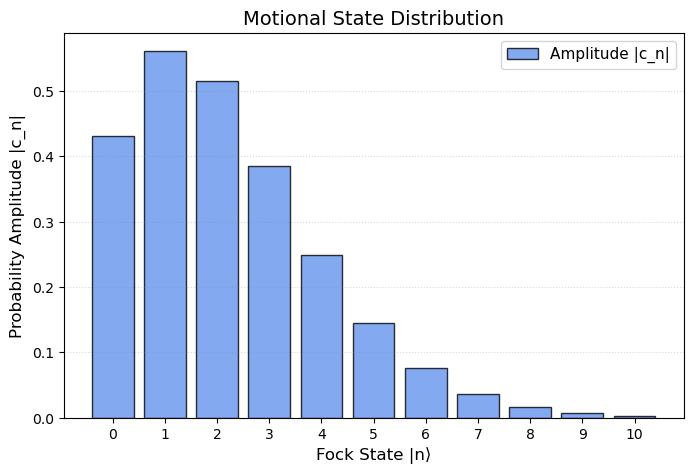

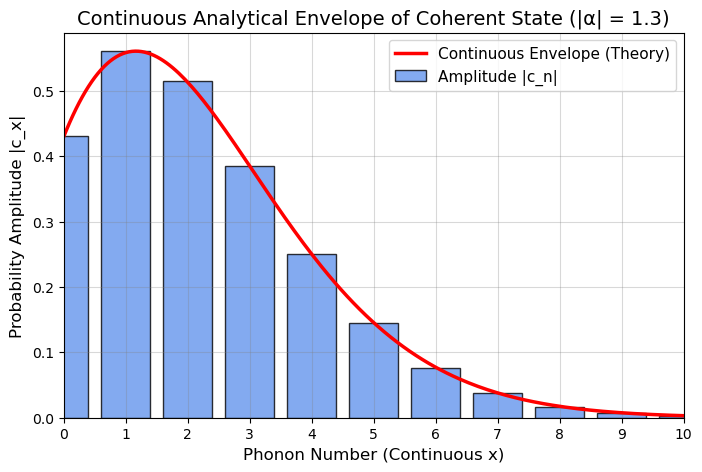

In [60]:
target_alpha = 1.3

experiment_base = SDF_apply_with_alpha(0, target_alpha, false,nothing,  0)
fig = extract_motional_ket(experiment_base)

x_continuous = range(0, stop=10, length=200)

analytical_continuous = @. exp(-target_alpha^2 / 2) * (target_alpha^x_continuous) / sqrt(gamma(x_continuous + 1))

PyPlot.plot(x_continuous, analytical_continuous, color="red", linewidth=2.5, linestyle="-", label="Continuous Envelope (Theory)")

PyPlot.xlim(0, 10) # Lock the X-axis from 0 to 10
PyPlot.xlabel("Phonon Number (Continuous x)", fontsize=12)
PyPlot.ylabel("Probability Amplitude |c_x|", fontsize=12)
PyPlot.title("Continuous Analytical Envelope of Coherent State (|α| = $target_alpha)", fontsize=14)

PyPlot.legend(loc="upper right", fontsize=11)
PyPlot.grid(which="major", color="gray", alpha=0.3, linestyle="-")

display(fig)

In [64]:
target_alpha = 1.0
experiment_base = SDF_apply_with_alpha(0, target_alpha, false,nothing,  0)
raw_data = experiment_base.data

g_amplitudes = raw_data[1:2:end]
motional_amplitudes = g_amplitudes .* sqrt(2)
mode_z = VibrationalMode(1.9e6, [1.0], axis=ẑ, N=10) # Ensure your mode has N=10 so dim=11 matches
motional_ket = Ket(mode_z, motional_amplitudes)


c_n_array = motional_ket.data
y_exp = abs.(c_n_array)
fock_states = 0:10 

y_theory = @. exp(-target_alpha^2 / 2) * (target_alpha^fock_states) / sqrt(gamma(fock_states + 1))

residuals = y_exp .- y_theory

rmse = sqrt(sum(residuals.^2) / length(y_exp))


ss_res = sum(residuals.^2) # Residual sum of squares
ss_tot = sum((y_exp .- mean(y_exp)).^2) # Total sum of squares
r_squared = 1.0 - (ss_res / ss_tot)

# ---------------------------------------------------------
# Print the Fit Results
# ---------------------------------------------------------
println("\n--- Goodness of Fit Analysis ---")
println("Target Alpha (|α|): ", target_alpha)
println("Root Mean Square Error (RMSE): ", rmse)
println("R-squared Fit (R²): ", r_squared)

# Show the exact difference array
println("\nExact Difference (Experiment - Theory) per state:")
for n in 0:10
    println("|", n, "⟩ difference: ", residuals[n+1])
end


--- Goodness of Fit Analysis ---
Target Alpha (|α|): 1.0
Root Mean Square Error (RMSE): 0.0013566630757437335
R-squared Fit (R²): 0.9999664535218112

Exact Difference (Experiment - Theory) per state:
|0⟩ difference: 0.0031550486620731677
|1⟩ difference: 0.002825762287281375
|2⟩ difference: 0.0012334043780844461
|3⟩ difference: -3.4202946170264203e-5
|4⟩ difference: -0.000542478558061818
|5⟩ difference: -0.00054395978206985
|6⟩ difference: -0.00037218457847349243
|7⟩ difference: -0.00020757172244862884
|8⟩ difference: -9.878550110519477e-5
|9⟩ difference: -5.042478162519705e-5
|10⟩ difference: 8.780749644251521e-6


In [66]:

c_0 = motional_ket.data[1]
c_1 = motional_ket.data[2]

extracted_magnitude = sqrt(-2 * log(abs(c_0)))

extracted_complex_alpha = c_1 / c_0

# ---------------------------------------------------------
# Print the Results
# ---------------------------------------------------------
println("Target Alpha (Input):      ", target_alpha)
println("Extracted Magnitude |α|:   ", extracted_magnitude)
println("Extracted Complex α:       ", extracted_complex_alpha)
println("Absolute Magnitude of Complex α: ", abs(extracted_complex_alpha))

Target Alpha (Input):      1.0
Extracted Magnitude |α|:   0.9947981571807395
Extracted Complex α:       -3.239872007302224e-5 + 0.9994599074729353im
Absolute Magnitude of Complex α: 0.9994599079980575
